In [14]:
import torch
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor, Lambda

torch.random.manual_seed(42)
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else "cpu"
learning_rate = 1e-3
batch_size = 64
epochs = 10

device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else "cpu"

train_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor(),
                      target_transform = Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(dim=0, index=torch.tensor(y), value=1)))
test_dataset = MNIST(root='./data', train=False, download=True, transform=ToTensor(),
                     target_transform = Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(dim=0, index=torch.tensor(y), value=1)))

device

device(type='cuda')

In [15]:
from torch.utils.data import Dataset, DataLoader

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [16]:
from torch import nn

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )
    
    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear(x)
        return logits

model = NeuralNetwork().to(device)
model

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)

In [17]:
def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()
    sum_loss = 0
    for (X, y) in dataloader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y.float())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        sum_loss += loss.item()

    return sum_loss / len(dataloader)

def test_loop(dataloader, model, loss_fn):
    model.eval()
    sum_loss = 0

    with torch.no_grad():
        for (X, y) in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            sum_loss += loss_fn(pred, y.float()).item()
    
    return sum_loss / len(dataloader)

In [18]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

for e in range(1, epochs + 1):
    print(f"Epoch {e}/{epochs} - Train entropy: {train_loop(train_loader, model, loss_fn, optimizer):.5}, test entropy: {test_loop(test_loader, model, loss_fn):.5}", end='\r')

In [19]:
torch.save(model, 'classification_model.pth')

In [20]:
model = torch.load('classification_model.pth', weights_only=False)
model.eval()

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)

In [31]:
def total_acc(dataloader, model, device):
    model.eval()
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            pred = nn.Softmax(dim=1)(pred).argmax(dim=1)
            y = y.argmax(dim=1)

            total_correct += (pred == y).sum().item()
            total_samples += y.size(0)
    
    return total_correct / total_samples

total_acc(test_loader, model, device)

0.9835

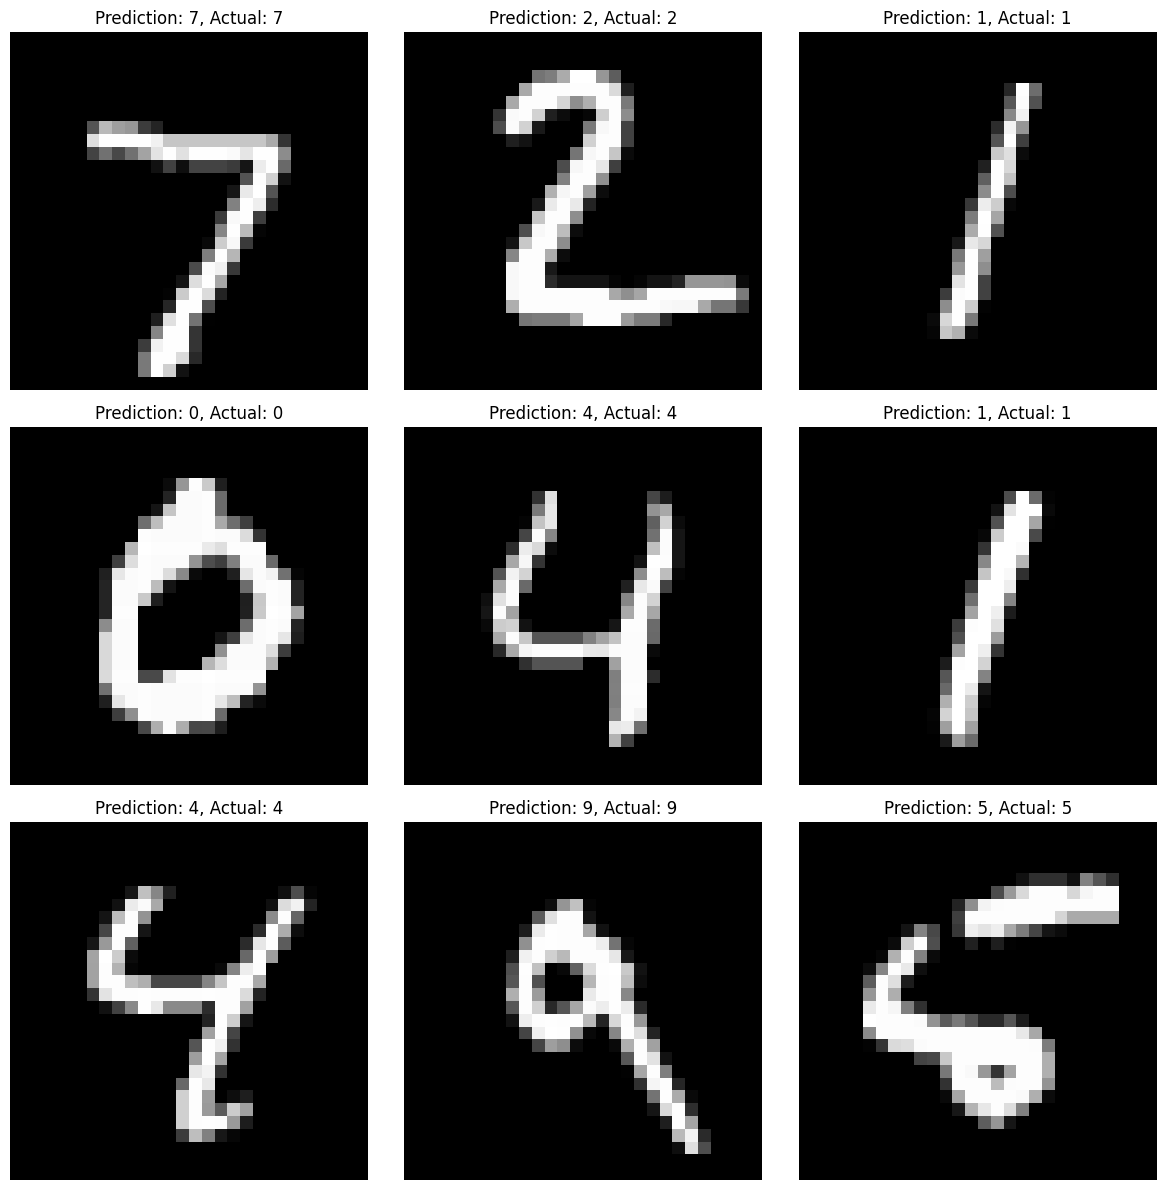

In [ ]:
import matplotlib.pyplot as plt

model.eval()

n, m = 3, 3
fig, axs = plt.subplots(n, m, figsize=(12, 12))

with torch.no_grad():
    for i in range(n):
        for j in range(m):
            X, y = test_dataset[i*m + j]
            X = X.to(device)

            logits = model(X.unsqueeze(0))
            pred = logits.argmax(dim=1).item()

            img = X[0].detach().cpu().squeeze()
            axs[i, j].imshow(img, cmap="gray")
            axs[i, j].set_title(f"Prediction: {pred}, Actual: {y.argmax()}")
            axs[i, j].axis("off")

plt.tight_layout()
plt.show()
